<a href="https://colab.research.google.com/github/EngenhariaSoftwarePUCRS/Inteligencia_Artificial/blob/develop/Trabalho01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [169]:
integrantes = ["Augusto Baldino", "Felipe Freitas", "Luiza Heller", "Maria Eduarda Maia", "Paola Lopes"]
useful_links = [
    "https://pandas.pydata.org/pandas-docs/version/1.0/user_guide/style.html",
    "https://www.geeksforgeeks.org/how-to-replace-values-in-column-based-on-condition-in-pandas/",
    "https://www.geeksforgeeks.org/how-to-add-header-row-to-a-pandas-dataframe/",
    "https://discuss.streamlit.io/t/is-it-possible-to-center-data-on-cell-like-excel/32045/7",
]

In [170]:
import pandas as pd
from matplotlib import pyplot
from seaborn.palettes import mpl_palette as colors
from sklearn import model_selection, neighbors
from typing import Literal

In [171]:
targetClass = "Win for X"
columnNames = [
    "Top-Left", "Top-Middle", "Top-Right",
    "Middle-Left", "Middle-Middle", "Middle-Right",
    "Bottom-Left", "Bottom-Middle", "Bottom-Right",
    targetClass,
]
dataset = pd.read_csv(
    "data/tic-tac-toe.data",
    names=columnNames,
)
dataLinesCount = 958

In [172]:
def cell_to_number(cell: Literal['b', 'x', 'o']):
  if cell == 'b':
    return 0

  if cell == 'x':
    return 1

  if cell == 'o':
    return -1

  return cell

In [173]:
dataset.head(5)

,Top-Left,Top-Middle,Top-Right,Middle-Left,Middle-Middle,Middle-Right,Bottom-Left,Bottom-Middle,Bottom-Right,Win for X
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive


In [174]:
for columnName in columnNames:
  dataset[columnName] = dataset[columnName].apply(cell_to_number)
dataset.head(5)

,Top-Left,Top-Middle,Top-Right,Middle-Left,Middle-Middle,Middle-Right,Bottom-Left,Bottom-Middle,Bottom-Right,Win for X
0,1,1,1,1,-1,-1,1,-1,-1,positive
1,1,1,1,1,-1,-1,-1,1,-1,positive
2,1,1,1,1,-1,-1,-1,-1,1,positive
3,1,1,1,1,-1,-1,-1,0,0,positive
4,1,1,1,1,-1,-1,0,-1,0,positive


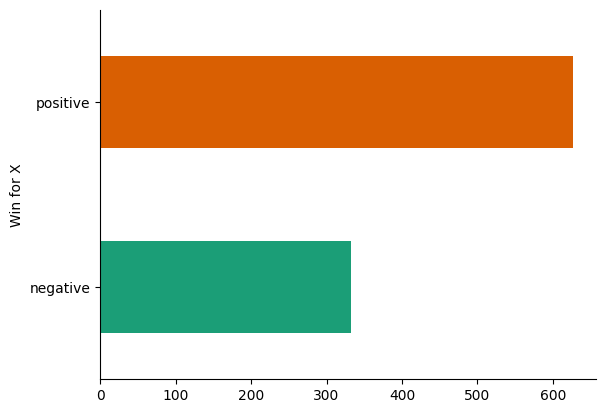

In [175]:
# @title Win for X
dataset.groupby('Win for X').size().plot(kind='barh', color=colors('Dark2'))
pyplot.gca().spines[['top', 'right',]].set_visible(False)

In [179]:
train_set, test_set = model_selection.train_test_split(dataset, train_size=0.8)

kNN_classifier = neighbors.KNeighborsClassifier(n_neighbors=5)

In [180]:
train_set_x = train_set.drop(columns=[targetClass])
train_set_y = train_set[targetClass]

kNN_classifier.fit(train_set_x, train_set_y)

KNeighborsClassifier()

In [181]:
test_set_x = test_set.drop(columns=[targetClass])
test_set_y = test_set[targetClass].values

predictions = kNN_classifier.predict(test_set_x)

success_count = 0
print('\t', "Esperado | Obtido")
for i in range(0, len(test_set_y)):
  if i == len(predictions):
    break
  if equals := (predictions[i] == test_set_y[i]):
    success_count += 1
    continue
  print("\033[31m", f"Erro na predição da linha {i}:", "\033[0m")
  print('\t', predictions[i], '|', test_set_y[i], '\n')

error_count = len(predictions) - success_count
if error_count == 0:
  # Remove print "Esperado | Obtido"
  print('\b' * len("\tEsperado | Obtido"))

print("Predições Corretas", '|', "Erros")
print('\t      ', success_count, '|', error_count)

	 Esperado | Obtido

Predições Corretas | Erros
	       192 | 0
